In [1]:
from pyspark import SparkContext

In [2]:
sc=SparkContext("local","PySparkIntro")

In [3]:
from pyspark.sql import SparkSession

In [4]:
spark=SparkSession.builder.appName("PySparkIntro").getOrCreate()

In [5]:
data=[1,2,3,4,5,7,8,9,10]
rdd=sc.parallelize(data)

In [6]:
square_rdd=rdd.map(lambda x:x*x)
even_rdd=rdd.filter(lambda x:x%2==0)

In [7]:
collect_square=square_rdd.collect()
number_of_elements=square_rdd.count()

In [8]:
from pyspark.sql.types import StructType,StructField,IntegerType,StringType

In [9]:
#Making schema using pyspark.sql

schema=StructType([
    StructField("id",IntegerType(),True),
    StructField("name",StringType(),True),
    StructField("Salary",IntegerType(),True),
    StructField("age",IntegerType(),True),
    StructField("city",StringType(),True),
])

In [10]:
data=[(1,"shaik",50000,25,"Hyderabad"),
        (2,"sai",60000,30,"Bangalore"),
        (3,"kumar",55000,28,"Chennai"),
        (4,"raju",70000,35,"Mumbai")
      ]

In [11]:
ds=spark.createDataFrame(data,schema)
ds.show()

+---+-----+------+---+---------+
| id| name|Salary|age|     city|
+---+-----+------+---+---------+
|  1|shaik| 50000| 25|Hyderabad|
|  2|  sai| 60000| 30|Bangalore|
|  3|kumar| 55000| 28|  Chennai|
|  4| raju| 70000| 35|   Mumbai|
+---+-----+------+---+---------+



In [12]:
df=ds.alias("employees")

In [13]:
data_file="enjoysport.csv"
df=spark.read.csv(data_file,header=False,inferSchema=True)

In [14]:
df.show()

+-----+----+------+------+----+------+---+
|  _c0| _c1|   _c2|   _c3| _c4|   _c5|_c6|
+-----+----+------+------+----+------+---+
|sunny|warm|normal|strong|warm|  same|yes|
|sunny|warm|  high|strong|warm|  same|yes|
|rainy|cold|  high|strong|warm|change| no|
|sunny|warm|  high|strong|cool|change|yes|
+-----+----+------+------+----+------+---+



In [15]:
df=spark.createDataFrame(data,schema)
df.show()

+---+-----+------+---+---------+
| id| name|Salary|age|     city|
+---+-----+------+---+---------+
|  1|shaik| 50000| 25|Hyderabad|
|  2|  sai| 60000| 30|Bangalore|
|  3|kumar| 55000| 28|  Chennai|
|  4| raju| 70000| 35|   Mumbai|
+---+-----+------+---+---------+



In [16]:
data_with_missing_values=[(1,"shaik",50000,25,"Hyderabad"),
        (2,"sai",60000,30,"Bangalore"),
        (3,"kumar",55000,28,None),
        (4,"raju",70000,None,"Mumbai")
]

In [17]:
df_with_missing_values=spark.createDataFrame(data_with_missing_values,schema)

mean_age=df_with_missing_values.select("age").agg({"age":"avg"}).collect()[0][0]

df_filled=df_with_missing_values.na.fill({"Salary":"mean"})

In [18]:
df_filled.show()

+---+-----+------+----+---------+
| id| name|Salary| age|     city|
+---+-----+------+----+---------+
|  1|shaik| 50000|  25|Hyderabad|
|  2|  sai| 60000|  30|Bangalore|
|  3|kumar| 55000|  28|     NULL|
|  4| raju| 70000|NULL|   Mumbai|
+---+-----+------+----+---------+



In [19]:
#Trying ML Lib with Pyspark
from pyspark.ml.feature import MinMaxScaler, StandardScaler
from pyspark.ml.feature import VectorAssembler

In [20]:
df=spark.createDataFrame(data,schema)

In [21]:
assembler=VectorAssembler(inputCols=["age","Salary"],outputCol="features")

In [22]:
scaled_data=assembler.transform(df)
scaled_data.show()

+---+-----+------+---+---------+--------------+
| id| name|Salary|age|     city|      features|
+---+-----+------+---+---------+--------------+
|  1|shaik| 50000| 25|Hyderabad|[25.0,50000.0]|
|  2|  sai| 60000| 30|Bangalore|[30.0,60000.0]|
|  3|kumar| 55000| 28|  Chennai|[28.0,55000.0]|
|  4| raju| 70000| 35|   Mumbai|[35.0,70000.0]|
+---+-----+------+---+---------+--------------+



In [23]:
scaled_min_max=MinMaxScaler(inputCol="features",outputCol="scaled_features")

scaled_min_max=scaled_min_max.fit(scaled_data)

scaled_min_max=scaled_min_max.transform(scaled_data)

scaled_min_max.show()

+---+-----+------+---+---------+--------------+--------------------+
| id| name|Salary|age|     city|      features|     scaled_features|
+---+-----+------+---+---------+--------------+--------------------+
|  1|shaik| 50000| 25|Hyderabad|[25.0,50000.0]|           [0.0,0.0]|
|  2|  sai| 60000| 30|Bangalore|[30.0,60000.0]|           [0.5,0.5]|
|  3|kumar| 55000| 28|  Chennai|[28.0,55000.0]|[0.30000000000000...|
|  4| raju| 70000| 35|   Mumbai|[35.0,70000.0]|           [1.0,1.0]|
+---+-----+------+---+---------+--------------+--------------------+



In [24]:
from pyspark.ml.feature import StandardScaler
scaler_standardization=StandardScaler(inputCol="features", outputCol="scaled_features", withStd=True, withMean=True)

In [25]:
scaler_standardization=scaler_standardization.fit(scaled_data).transform(scaled_data)

In [26]:
from  pyspark.sql.functions import mean, stddev

In [27]:
summary_stats=df.describe(["age","Salary"])
summary_stats.show()

+-------+-----------------+-----------------+
|summary|              age|           Salary|
+-------+-----------------+-----------------+
|  count|                4|                4|
|   mean|             29.5|          58750.0|
| stddev|4.203173404306163|8539.125638299665|
|    min|               25|            50000|
|    max|               35|            70000|
+-------+-----------------+-----------------+



In [28]:
import pandas as pd
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [29]:
pd_df=df.toPandas()

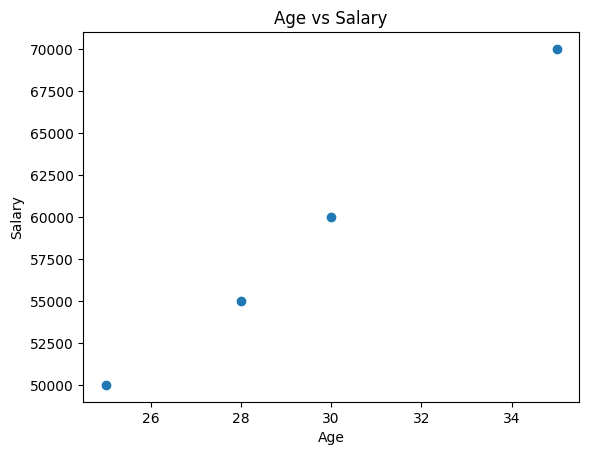

In [30]:
plt.scatter(pd_df["age"],pd_df["Salary"])
plt.xlabel("Age")
plt.ylabel("Salary")
plt.title("Age vs Salary")
plt.show()

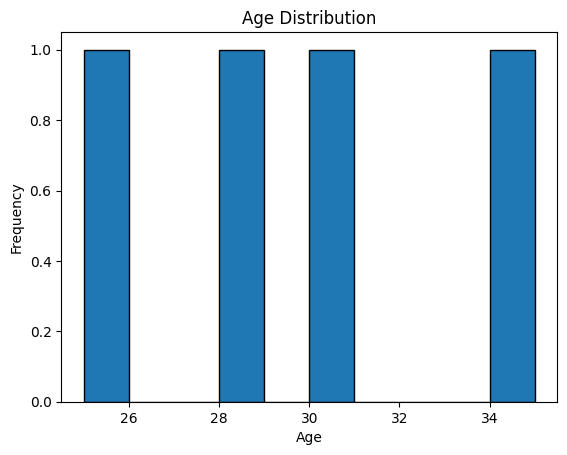

In [31]:
plt.hist(pd_df["age"], bins=10, edgecolor="black")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age Distribution")
plt.show()

In [32]:
correlation=df.stat.corr("age","Salary")
print("Correlation between age and Salary:", correlation)

Correlation between age and Salary: 0.9983814394570298


In [33]:
from pyspark.sql.functions import col

df_transformed=df.withColumn("Increased Salary",col("Salary")*1.5)

df_transformed.show()

+---+-----+------+---+---------+----------------+
| id| name|Salary|age|     city|Increased Salary|
+---+-----+------+---+---------+----------------+
|  1|shaik| 50000| 25|Hyderabad|         75000.0|
|  2|  sai| 60000| 30|Bangalore|         90000.0|
|  3|kumar| 55000| 28|  Chennai|         82500.0|
|  4| raju| 70000| 35|   Mumbai|        105000.0|
+---+-----+------+---+---------+----------------+



In [34]:
from pyspark.sql.functions import concat, lit

In [35]:
df_transformed=df.withColumn("Name and Postition",concat(col("name"), lit(" - Employee")))

df_transformed.show()

+---+-----+------+---+---------+------------------+
| id| name|Salary|age|     city|Name and Postition|
+---+-----+------+---+---------+------------------+
|  1|shaik| 50000| 25|Hyderabad|  shaik - Employee|
|  2|  sai| 60000| 30|Bangalore|    sai - Employee|
|  3|kumar| 55000| 28|  Chennai|  kumar - Employee|
|  4| raju| 70000| 35|   Mumbai|   raju - Employee|
+---+-----+------+---+---------+------------------+



In [36]:
df_filtered=df.filter(col("age")>=30)

df_filtered.show()

+---+----+------+---+---------+
| id|name|Salary|age|     city|
+---+----+------+---+---------+
|  2| sai| 60000| 30|Bangalore|
|  4|raju| 70000| 35|   Mumbai|
+---+----+------+---+---------+



In [37]:
from pyspark.sql.functions import avg

average_salary=df.agg(avg("Salary")).collect()[0][0]

average_salary

58750.0

In [38]:
from pyspark.sql.functions import min, max

grouped_data=df.groupBy("age").agg(avg("Salary"),max("Salary"),min("Salary"))

grouped_data.show()

+---+-----------+-----------+-----------+
|age|avg(Salary)|max(Salary)|min(Salary)|
+---+-----------+-----------+-----------+
| 28|    55000.0|      55000|      55000|
| 35|    70000.0|      70000|      70000|
| 25|    50000.0|      50000|      50000|
| 30|    60000.0|      60000|      60000|
+---+-----------+-----------+-----------+



In [39]:
from pyspark.sql.functions import sum
from pyspark.sql.window import Window

In [40]:
#Getting cumulative sum of Salary based on age

window_spec=Window.orderBy("age")

df_with_cum_sum=df.withColumn("Cumulative Salary",sum("Salary").over(window_spec))

df_with_cum_sum.show()

+---+-----+------+---+---------+-----------------+
| id| name|Salary|age|     city|Cumulative Salary|
+---+-----+------+---+---------+-----------------+
|  1|shaik| 50000| 25|Hyderabad|            50000|
|  3|kumar| 55000| 28|  Chennai|           105000|
|  2|  sai| 60000| 30|Bangalore|           165000|
|  4| raju| 70000| 35|   Mumbai|           235000|
+---+-----+------+---+---------+-----------------+



In [41]:
def add_prefix(name):
    return "Employee: Mr." + name

In [42]:
from pyspark.sql.functions import udf
from pyspark.sql.types import StringType

In [43]:
add_prefix_udf=udf(add_prefix, StringType())

In [44]:
df_prefixed=df.withColumn("Prefixed Name",add_prefix_udf(col("name")))

df_prefixed.show()

+---+-----+------+---+---------+------------------+
| id| name|Salary|age|     city|     Prefixed Name|
+---+-----+------+---+---------+------------------+
|  1|shaik| 50000| 25|Hyderabad|Employee: Mr.shaik|
|  2|  sai| 60000| 30|Bangalore|  Employee: Mr.sai|
|  3|kumar| 55000| 28|  Chennai|Employee: Mr.kumar|
|  4| raju| 70000| 35|   Mumbai| Employee: Mr.raju|
+---+-----+------+---+---------+------------------+



In [45]:
def calculate_total_income(salary, age):
    return salary * age

In [46]:
from pyspark.sql.types import IntegerType

calculated_total_income_udf=udf(calculate_total_income, IntegerType())

df_with_calculate_total_income=df.withColumn("Total Income(MeaningLes)", calculated_total_income_udf(col("Salary"), col("age")))

df_with_calculate_total_income.show()

+---+-----+------+---+---------+------------------------+
| id| name|Salary|age|     city|Total Income(MeaningLes)|
+---+-----+------+---+---------+------------------------+
|  1|shaik| 50000| 25|Hyderabad|                 1250000|
|  2|  sai| 60000| 30|Bangalore|                 1800000|
|  3|kumar| 55000| 28|  Chennai|                 1540000|
|  4| raju| 70000| 35|   Mumbai|                 2450000|
+---+-----+------+---+---------+------------------------+



In [47]:
spark=SparkSession.builder.appName("SupervisedML").getOrCreate()

In [48]:
#making own house price dataset
data=[(1200,2,1,15000),
      (1500,3,0,20000),
      (1800,4,1,25000),
      (2000,5,0,30000),
      (2200,6,1,35000),
      (2500,7,0,40000),
      (2800,8,1,45000),
      (3000,9,0,50000)
     ]

In [49]:
from pyspark.sql.types import FloatType,IntegerType, StructType, StructField

In [50]:
schema=StructType([
    StructField("SqFt", IntegerType(), True),
    StructField("Bedrooms", IntegerType(), True),
    StructField("Bathrooms", IntegerType(), True),
    StructField("Price", IntegerType(), True)
])

In [51]:
df=spark.createDataFrame(data, schema)
df.show()

+----+--------+---------+-----+
|SqFt|Bedrooms|Bathrooms|Price|
+----+--------+---------+-----+
|1200|       2|        1|15000|
|1500|       3|        0|20000|
|1800|       4|        1|25000|
|2000|       5|        0|30000|
|2200|       6|        1|35000|
|2500|       7|        0|40000|
|2800|       8|        1|45000|
|3000|       9|        0|50000|
+----+--------+---------+-----+



In [52]:
from pyspark.ml.feature import VectorAssembler
# from pyspark.ml.regression import LinearRegression
from pyspark.ml.classification import LogisticRegression
from pyspark.ml import Pipeline

In [53]:
featured_cols=["SqFt","Bedrooms","Bathrooms"]
assembler=VectorAssembler(inputCols=featured_cols, outputCol="features")

In [54]:
df_assembled=assembler.transform(df)

train_data, test_data=df_assembled.randomSplit([0.8,0.2])

lr=LogisticRegression(featuresCol="features", labelCol="Price")

model=lr.fit(train_data)

predictions=model.transform(test_data)

predictions.select("features","Price","prediction").show()

+----------------+-----+----------+
|        features|Price|prediction|
+----------------+-----+----------+
|[2000.0,5.0,0.0]|30000|   40000.0|
|[2800.0,8.0,1.0]|45000|   35000.0|
+----------------+-----+----------+



In [55]:
from pyspark.ml.regression import LinearRegression

In [56]:
linear_reg=LinearRegression(featuresCol="features", labelCol="Price")
model=linear_reg.fit(train_data)

predictions=model.transform(test_data)
predictions.select("features","Price","prediction").show()

+----------------+-----+------------------+
|        features|Price|        prediction|
+----------------+-----+------------------+
|[2000.0,5.0,0.0]|30000|30000.000000000033|
|[2800.0,8.0,1.0]|45000| 45000.00000000023|
+----------------+-----+------------------+



In [57]:
data=[("Customer1",10000,5000,2000),
      ("Customer2",15000,7000,3000),
      ("Customer3",20000,10000,5000),
      ("Customer4",25000,12000,6000),
      ("Customer5",30000,15000,8000),
      ("Customer6",35000,20000,10000),
      ("Customer7",40000,25000,12000)
     ]

In [58]:
schema=StructType([
    StructField("Customers",StringType(),True),
    StructField("Spending_on_electronics",IntegerType(),True),
    StructField("Spending_on_clothing",IntegerType(),True),
    StructField("Spending_on_grocery",IntegerType(),True)
])

In [59]:
df=spark.createDataFrame(data, schema)
df.show()

+---------+-----------------------+--------------------+-------------------+
|Customers|Spending_on_electronics|Spending_on_clothing|Spending_on_grocery|
+---------+-----------------------+--------------------+-------------------+
|Customer1|                  10000|                5000|               2000|
|Customer2|                  15000|                7000|               3000|
|Customer3|                  20000|               10000|               5000|
|Customer4|                  25000|               12000|               6000|
|Customer5|                  30000|               15000|               8000|
|Customer6|                  35000|               20000|              10000|
|Customer7|                  40000|               25000|              12000|
+---------+-----------------------+--------------------+-------------------+



In [60]:
from pyspark.ml.clustering import KMeans

In [61]:
feature_cols=["Spending_on_electronics","Spending_on_clothing","Spending_on_grocery"]

assembler=VectorAssembler(inputCols=feature_cols, outputCol="features")

In [62]:
df_assembled=assembler.transform(df)

kmeans=KMeans(featuresCol="features", k=3)

model=kmeans.fit(df_assembled)

In [63]:
predictions=model.transform(df_assembled)
predictions.select("features","Customers","prediction").show()

+--------------------+---------+----------+
|            features|Customers|prediction|
+--------------------+---------+----------+
|[10000.0,5000.0,2...|Customer1|         1|
|[15000.0,7000.0,3...|Customer2|         1|
|[20000.0,10000.0,...|Customer3|         1|
|[25000.0,12000.0,...|Customer4|         0|
|[30000.0,15000.0,...|Customer5|         0|
|[35000.0,20000.0,...|Customer6|         2|
|[40000.0,25000.0,...|Customer7|         2|
+--------------------+---------+----------+



In [64]:
#PCA for dimensionality reduction
from pyspark.ml.feature import PCA

In [65]:
pca=PCA(k=2, inputCol="features", outputCol="pca_features")

model=pca.fit(df_assembled)

In [66]:
df_pca=model.transform(df_assembled)
df_pca.select("features","pca_features").show(truncate=False)

+-------------------------+----------------------------------------+
|features                 |pca_features                            |
+-------------------------+----------------------------------------+
|[10000.0,5000.0,2000.0]  |[-11229.141711739972,1429.232559441872] |
|[15000.0,7000.0,3000.0]  |[-16579.516158631,2550.210700822566]    |
|[20000.0,10000.0,5000.0] |[-22729.78723747192,2746.2172320019263] |
|[25000.0,12000.0,6000.0] |[-28080.16168436294,3867.195373382621]  |
|[30000.0,15000.0,8000.0] |[-34230.43276320386,4063.2019045619804] |
|[35000.0,20000.0,10000.0]|[-41437.48947796065,2633.7609891023076] |
|[40000.0,25000.0,12000.0]|[-48644.546192717426,1204.3200736426322]|
+-------------------------+----------------------------------------+

